# Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**


# Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


#  Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



#  Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


# Compare Training Loss

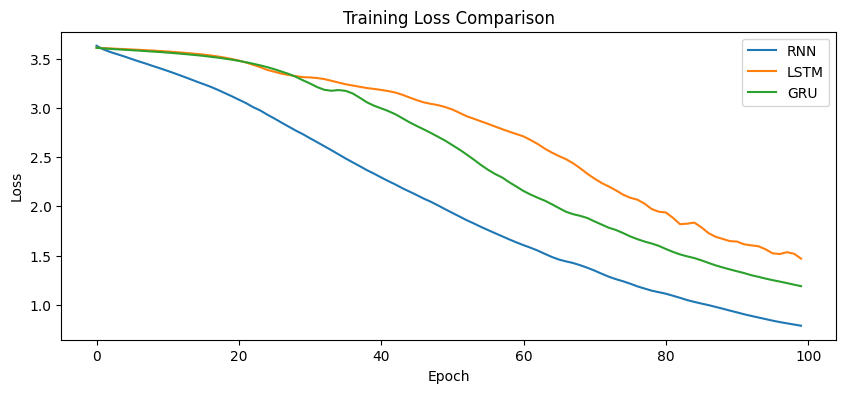

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

##  Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning is transforming artificial intelligence meaningful
GRU : deep learning is transforming artificial intelligence intelligence


#  Student Learning Tasks
###  Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

### 1. Replace corpus with your own paragraph

In [10]:
corpus_v2='''THE SONNETS
by William Shakespeare
From fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou contracted to thine own bright eyes,
Feed'st thy light's flame with self-substantial fuel,
Making a famine where abundance lies,
Thy self thy foe, to thy sweet self too cruel:
Thou that art now the world's fresh ornament,
And only herald to the gaudy spring,
Within thine own bud buriest thy content,
And tender churl mak'st waste in niggarding:
Pity the world, or else this glutton be,
To eat the world's due, by the grave and thee.
When forty winters shall besiege thy brow,
And dig deep trenches in thy beauty's field,
Thy youth's proud livery so gazed on now,
Will be a tattered weed of small worth held:
Then being asked, where all thy beauty lies,
Where all the treasure of thy lusty days;
To say within thine own deep sunken eyes,
Were an all-eating shame, and thriftless praise.
How much more praise deserved thy beauty's use,
If thou couldst answer 'This fair child of mine
Shall sum my count, and make my old excuse'
Proving his beauty by succession thine.
This were to be new made when thou art old,
And see thy blood warm when thou feel'st it cold.
Look in thy glass and tell the face thou viewest,
Now is the time that face should form another,
Whose fresh repair if now thou not renewest,
Thou dost beguile the world, unbless some mother.
For where is she so fair whose uneared womb
Disdains the tillage of thy husbandry?
Or who is he so fond will be the tomb,
Of his self-love to stop posterity?
Thou art thy mother's glass and she in thee
Calls back the lovely April of her prime,
So thou through windows of thine age shalt see,
Despite of wrinkles this thy golden time.
But if thou live remembered not to be,
Die single and thine image dies with thee.
Unthrifty loveliness why dost thou spend,
Upon thy self thy beauty's legacy?
Nature's bequest gives nothing but doth lend,
And being frank she lends to those are free:
Then beauteous niggard why dost thou abuse,
The bounteous largess given thee to give?
Profitless usurer why dost thou use
So great a sum of sums yet canst not live?
For having traffic with thy self alone,
Thou of thy self thy sweet self dost deceive,
Then how when nature calls thee to be gone,
What acceptable audit canst thou leave?
Thy unused beauty must be tombed with thee,
Which used lives th' executor to be.
Those hours that with gentle work did frame
The lovely gaze where every eye doth dwell
Will play the tyrants to the very same,
And that unfair which fairly doth excel:
For never-resting time leads summer on
To hideous winter and confounds him there,
Sap checked with frost and lusty leaves quite gone,
Beauty o'er-snowed and bareness every where:
Then were not summer's distillation left
A liquid prisoner pent in walls of glass,
Beauty's effect with beauty were bereft,
Nor it nor no remembrance what it was.
But flowers distilled though they with winter meet,
Leese but their show, their substance still lives sweet.
'''
print(corpus_v2)

THE SONNETS
by William Shakespeare
From fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou contracted to thine own bright eyes,
Feed'st thy light's flame with self-substantial fuel,
Making a famine where abundance lies,
Thy self thy foe, to thy sweet self too cruel:
Thou that art now the world's fresh ornament,
And only herald to the gaudy spring,
Within thine own bud buriest thy content,
And tender churl mak'st waste in niggarding:
Pity the world, or else this glutton be,
To eat the world's due, by the grave and thee.
When forty winters shall besiege thy brow,
And dig deep trenches in thy beauty's field,
Thy youth's proud livery so gazed on now,
Will be a tattered weed of small worth held:  
Then being asked, where all thy beauty lies,
Where all the treasure of thy lusty days;
To say within thine own deep sunken eyes,
Were an all-eating shame, and thriftless praise.


### 2. Increase embedding dimension

In [11]:
tokenizer_v2=Tokenizer()
tokenizer_v2.fit_on_texts([corpus_v2])
total_words_v2=len(tokenizer_v2.word_index)+1
print("Vocabulary size:",total_words_v2)
input_sequences_v2 = []
for line in corpus_v2.split('\n'):
    token_list=tokenizer_v2.texts_to_sequences([line])[0]
    for i in range(1,len(token_list)):
        n_gram_seq=token_list[:i+1]
        input_sequences_v2.append(n_gram_seq)
max_len_v2=max(len(seq) for seq in input_sequences_v2)
input_sequences_v2=pad_sequences(input_sequences_v2,maxlen=max_len_v2,padding='pre')

X_v2=input_sequences_v2[:,:-1]
y_v2=input_sequences_v2[:,-1]

print("X shape:",X_v2.shape)
print("y shape:",y_v2.shape)

Vocabulary size: 305
X shape: (482, 9)
y shape: (482,)


### 3. Increase epochs to 200

In [12]:
rnn_model_v2=Sequential([
    Embedding(total_words_v2,64,input_length=max_len_v2-1),
    SimpleRNN(128),
    Dense(total_words_v2,activation='softmax')
])
rnn_model_v2.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])
rnn_history_v2 = rnn_model_v2.fit(X_v2, y_v2,epochs=200,verbose=0)
print("Vanilla RNN(v2) training completed")

Vanilla RNN(v2) training completed


In [13]:
lstm_model_v2=Sequential([
    Embedding(total_words_v2,64,input_length=max_len_v2-1),
    LSTM(128),
    Dense(total_words_v2,activation='softmax')
])
lstm_model_v2.compile(loss='sparse_categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])
lstm_history_v2=lstm_model_v2.fit(X_v2, y_v2,epochs=200,verbose=0)
print("LSTM (v2) training completed")

LSTM (v2) training completed


In [14]:
gru_model_v2=Sequential([
    Embedding(total_words_v2,64,input_length=max_len_v2-1),
    GRU(128),
    Dense(total_words_v2,activation='softmax')
])
gru_model_v2.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])
gru_history_v2=gru_model_v2.fit(X_v2, y_v2,epochs=200,verbose=0)
print("GRU(v2)training completed")

GRU(v2)training completed


### 4. Change hidden units 64 → 128

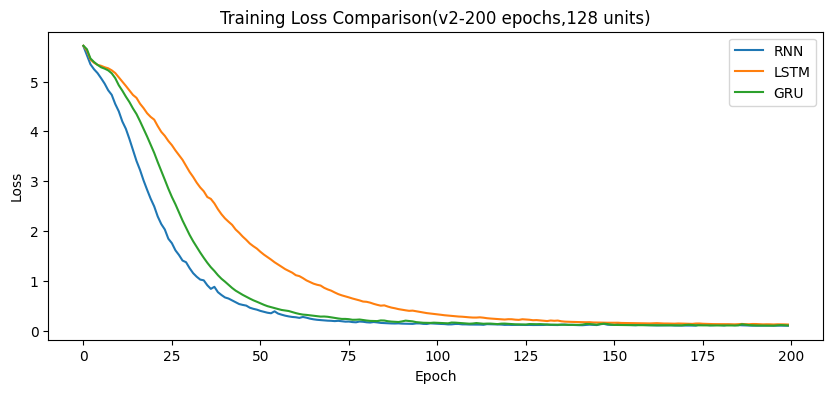

In [15]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history_v2.history['loss'],label='RNN')
plt.plot(lstm_history_v2.history['loss'],label='LSTM')
plt.plot(gru_history_v2.history['loss'],label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison(v2-200 epochs,128 units)")
plt.legend()
plt.show()

### 5. Generate 10 words instead of 5

In [16]:
def generate_text_v2(model,seed_text,next_words=10):
    for _ in range(next_words):
        token_list=tokenizer_v2.texts_to_sequences([seed_text])[0]
        token_list=pad_sequences([token_list],maxlen=max_len_v2-1, padding='pre')
        predicted=np.argmax(model.predict(token_list,verbose=0),axis=-1)[0]

        output_word= ""
        for word,index in tokenizer_v2.word_index.items():
            if index==predicted:
                output_word=word
                break
        seed_text+=" " +output_word
    return seed_text
print("RNN :",generate_text_v2(rnn_model_v2,"to be",10))
print("LSTM:",generate_text_v2(lstm_model_v2,"to be",10))
print("GRU :",generate_text_v2(gru_model_v2,"to be",10))

RNN : to be within thine own deep sunken eyes content deceive leave by
LSTM: to be a sum of sums yet canst not live held womb
GRU : to be a tattered weed of small worth held womb womb womb


#  Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**